# Analyse de la convergence technologique : Les Biotechnologies de diagnostic
## Étude de cas : C12N (Biologie moléculaire) × G01N (Instrumentation analytique)

---

## Contexte et objectif

Les biotechnologies de diagnostic constituent un exemple de convergence
entre deux domaines radicalement différents :

- **C12N** — *Micro-organismes, enzymes, génie génétique* : ADN recombinant,
  vecteurs d'expression, culture cellulaire, CRISPR. Domaine issu de la
  biologie moléculaire et de la biochimie.

- **G01N** — *Analyse et mesure des propriétés des matériaux* :
  spectroscopie, chromatographie, immunoanalyse, PCR quantitative,
  capteurs biologiques. Domaine issu de la chimie analytique et
  de l'instrumentation de précision.

L'émergence des biotechnologies de diagnostic est datée autour de
**1995-2000** : PCR (Polymerase Chain Reaction) commercialisée dès 1991,
puis explosion des tests diagnostics moléculaires (VIH, hépatites,
diagnostic prénatal) dans la seconde moitié des années 1990.

## Pourquoi ce cas ?

Ce cas est différent des deux précédents sur deux points importants :

**1. L'émergence est plus précoce** (1995-2000 vs 2007 et 2012) — on est
en début de la fenêtre 1988-2022, ce qui testera la robustesse des
méthodes sur des signaux anciens.

**2. La nature de la convergence est différente** — C12N et G01N ne
créent pas un objet industriel unique comme le VE ou le smartphone.
Ils forment un *écosystème technologique* : les outils de mesure
deviennent biologiques, et la biologie devient mesurable avec précision.
C'est peut-être une convergence plus symétrique que les deux premiers cas.

## Démarche

Même structure que les deux notebooks précédents.
On compare ensuite les trois profils pour identifier
la signature commune de la convergence technologique.

## 0. Imports, paramètres et données

In [6]:
import pandas as pd
import numpy as np
import itertools
from collections import Counter, defaultdict
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
import networkx as nx
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════
# PALETTE DE COULEURS
# ════════════════════════════════════════════════════════════════
C_I       = '#16A085'   # vert teal — C12N (Biologie moléculaire)
C_J       = '#8E44AD'   # violet   — G01N (Instrumentation analytique)
C_JACCARD = '#1B4332'   # vert foncé — Jaccard
C_RUPTURE = '#C0392B'   # rouge    — ruptures
C_EMERGE  = '#7F8C8D'   # gris     — date d'émergence connue
C_COMMUN  = '#E07B39'   # orange   — voisins communs
C_POS     = '#A9DFBF'   # vert clair — corrélation positive
C_NEG     = '#F1948A'   # rouge clair — corrélation négative

# ════════════════════════════════════════════════════════════════
# PARAMÈTRES
# ════════════════════════════════════════════════════════════════
WINDOW      = 5
SMOOTH_W    = 3
K_CLUSTERS  = 10
N_PCA       = 20
N_NEIGHBORS = 5
CORR_WINDOW = 5

YEAR_START  = 1988
YEAR_END    = 2022
YEAR_EMERGE = 1997
# Justification : 1997 est la date médiane de l'émergence des
# biotechnologies de diagnostic moléculaire — PCR diagnostique
# commercialisée, premiers tests VIH, explosion de l'immunodiagnostic.

CPC_I = 'C12N'  # Biologie moléculaire, micro-organismes, génie génétique
CPC_J = 'G01N'  # Analyse et mesure des propriétés des matériaux

print(f'Analyse : {CPC_I} (Biologie moléculaire) × {CPC_J} (Instrumentation analytique)')
print(f'Période : {YEAR_START}–{YEAR_END} | Émergence connue : {YEAR_EMERGE}')

Analyse : C12N (Biologie moléculaire) × G01N (Instrumentation analytique)
Période : 1988–2022 | Émergence connue : 1997


In [2]:
df_raw = pd.read_parquet('multi_codes_brevets.parquet')
df_raw = df_raw.dropna(subset=['year', 'cpc4_list']).copy()
df_raw['year'] = df_raw['year'].astype(int)

def normalize_cpc(lst):
    clean = []
    for c in lst:
        if c is None: continue
        s = str(c).upper().strip()
        if len(s) >= 4: clean.append(s[:4])
    return sorted(set(clean))

df_raw['cpc4'] = df_raw['cpc4_list'].apply(normalize_cpc)
df_raw = df_raw[
    (df_raw['cpc4'].apply(len) >= 2) &
    (df_raw['year'] >= YEAR_START) &
    (df_raw['year'] <= YEAR_END)
].copy()

brevet_by_year = df_raw.groupby('year').size().to_dict()
N_mean = np.mean(list(brevet_by_year.values()))

n_i  = df_raw['cpc4'].apply(lambda x: CPC_I in x).sum()
n_j  = df_raw['cpc4'].apply(lambda x: CPC_J in x).sum()
n_ij = df_raw['cpc4'].apply(lambda x: CPC_I in x and CPC_J in x).sum()

print(f'Brevets chargés : {len(df_raw):,}')
print(f'Brevets contenant {CPC_I} : {n_i:,}')
print(f'Brevets contenant {CPC_J} : {n_j:,}')
print(f'Brevets contenant les deux : {n_ij:,}')
print(f'Part de {CPC_J} dans {CPC_I} : {n_ij/n_i:.1%}')
print(f'Part de {CPC_I} dans {CPC_J} : {n_ij/n_j:.1%}')

Brevets chargés : 1,066,765
Brevets contenant C12N : 34,191
Brevets contenant G01N : 47,903
Brevets contenant les deux : 5,127
Part de G01N dans C12N : 15.0%
Part de C12N dans G01N : 10.7%


---
# MÉTHODE 1 — Centralité (Strength)

**Particularité de ce cas** : l'émergence est en 1997 — très tôt dans
notre fenêtre temporelle (1988-2022). On s'attend à voir les ruptures
de centralité en début de série, là où le réseau est encore petit.
Cela testera la robustesse de la méthode sur des signaux précoces.

C12N et G01N sont deux codes avec une histoire longue bien avant 1988 :
la biologie moléculaire existe depuis les années 1950,
et l'instrumentation analytique depuis encore plus longtemps.
On cherche le moment où leur *rapprochement spécifique* s'accélère.

In [3]:
def compute_strength_series(df, cpc_list, window=WINDOW):
    records = []
    for t in range(YEAR_START, YEAR_END+1):
        df_w = df[(df['year']>=t-window//2) & (df['year']<=t+window//2)]
        strength = defaultdict(float)
        for _,row in df_w.iterrows():
            codes=row['cpc4']; m=len(codes)
            if m<2: continue
            yr=row['year']
            w=(2.0/(m*(m-1)))*(N_mean/brevet_by_year.get(yr,N_mean))
            for ci,cj in itertools.combinations(codes,2):
                if ci in cpc_list: strength[ci]+=w
                if cj in cpc_list: strength[cj]+=w
        for cpc in cpc_list:
            records.append({'year':t,'cpc4':cpc,'strength':strength.get(cpc,0.)})
    return pd.DataFrame(records)

def smooth(y, w=SMOOTH_W):
    return pd.Series(y).rolling(w,center=True,min_periods=2).mean().values

def detect_two_breaks(x, y, min_len=4):
    def rss(xs,ys):
        if len(xs)<2: return 0
        p=np.polyfit(xs.astype(float),ys,1)
        return np.sum((ys-np.polyval(p,xs.astype(float)))**2)
    best_rss=np.inf; best_k1=best_k2=len(x)//3
    for k1 in range(min_len,len(x)-2*min_len):
        for k2 in range(k1+min_len,len(x)-min_len):
            r=rss(x[:k1],y[:k1])+rss(x[k1:k2],y[k1:k2])+rss(x[k2:],y[k2:])
            if r<best_rss: best_rss=r; best_k1=k1; best_k2=k2
    return sorted([int(x[best_k1]),int(x[best_k2])])

print('Calcul du strength...')
df_str = compute_strength_series(df_raw, [CPC_I, CPC_J])
s_i=df_str[df_str['cpc4']==CPC_I].sort_values('year')
s_j=df_str[df_str['cpc4']==CPC_J].sort_values('year')
xi,yi=s_i['year'].values,s_i['strength'].values
xj,yj=s_j['year'].values,s_j['strength'].values
yi_s=smooth(yi); yj_s=smooth(yj)
breaks_i=detect_two_breaks(xi,yi_s)
breaks_j=detect_two_breaks(xj,yj_s)
print(f'Ruptures {CPC_I} : {breaks_i}')
print(f'Ruptures {CPC_J} : {breaks_j}')

Calcul du strength...
Ruptures C12N : [2005, 2017]
Ruptures G01N : [1996, 2018]


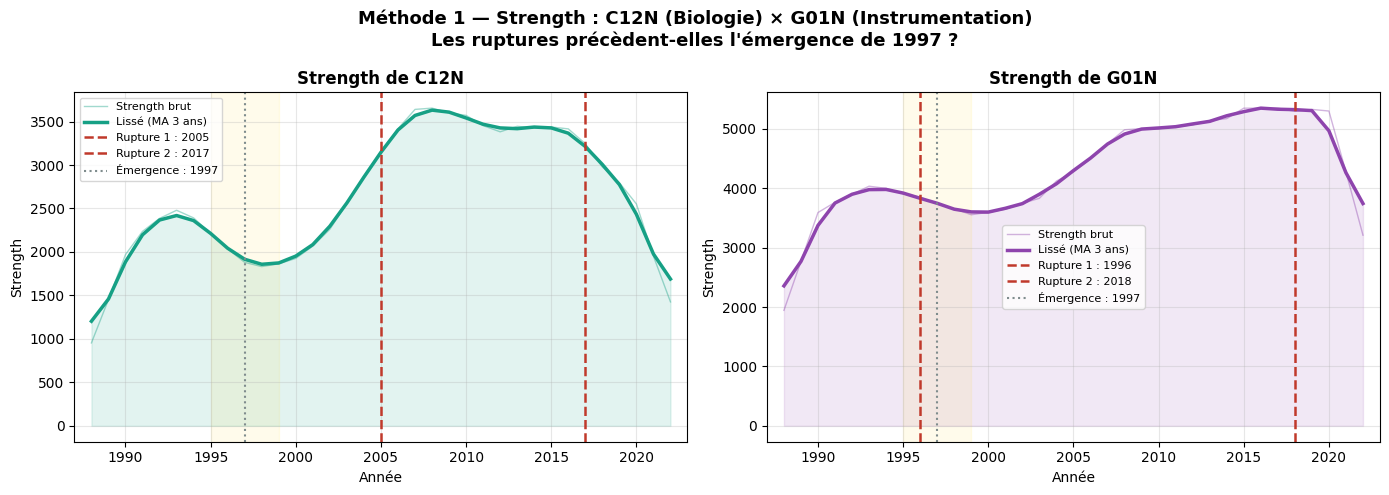

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax,(x,y,ys,brk,cpc,color) in zip(axes,[
    (xi,yi,yi_s,breaks_i,CPC_I,C_I),
    (xj,yj,yj_s,breaks_j,CPC_J,C_J)
]):
    ax.fill_between(x,0,ys,alpha=0.12,color=color)
    ax.plot(x,y,color=color,lw=1,alpha=0.4,label='Strength brut')
    ax.plot(x,ys,color=color,lw=2.5,label=f'Lissé (MA {SMOOTH_W} ans)')
    for i,b in enumerate(brk):
        ax.axvline(b,color=C_RUPTURE,ls='--',lw=1.8,label=f'Rupture {i+1} : {b}')
    ax.axvline(YEAR_EMERGE,color=C_EMERGE,ls=':',lw=1.5,
               label=f'Émergence : {YEAR_EMERGE}')
    ax.axvspan(YEAR_EMERGE-2,YEAR_EMERGE+2,alpha=0.08,color='gold')
    ax.set_title(f'Strength de {cpc}',fontweight='bold',fontsize=12)
    ax.set_xlabel('Année'); ax.set_ylabel('Strength')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlim(YEAR_START-1,YEAR_END+1)
plt.suptitle('Méthode 1 — Strength : C12N (Biologie) × G01N (Instrumentation)\n'
             'Les ruptures précèdent-elles l\'émergence de 1997 ?',
             fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('M1_strength_biotech.png',dpi=150,bbox_inches='tight')
plt.show()

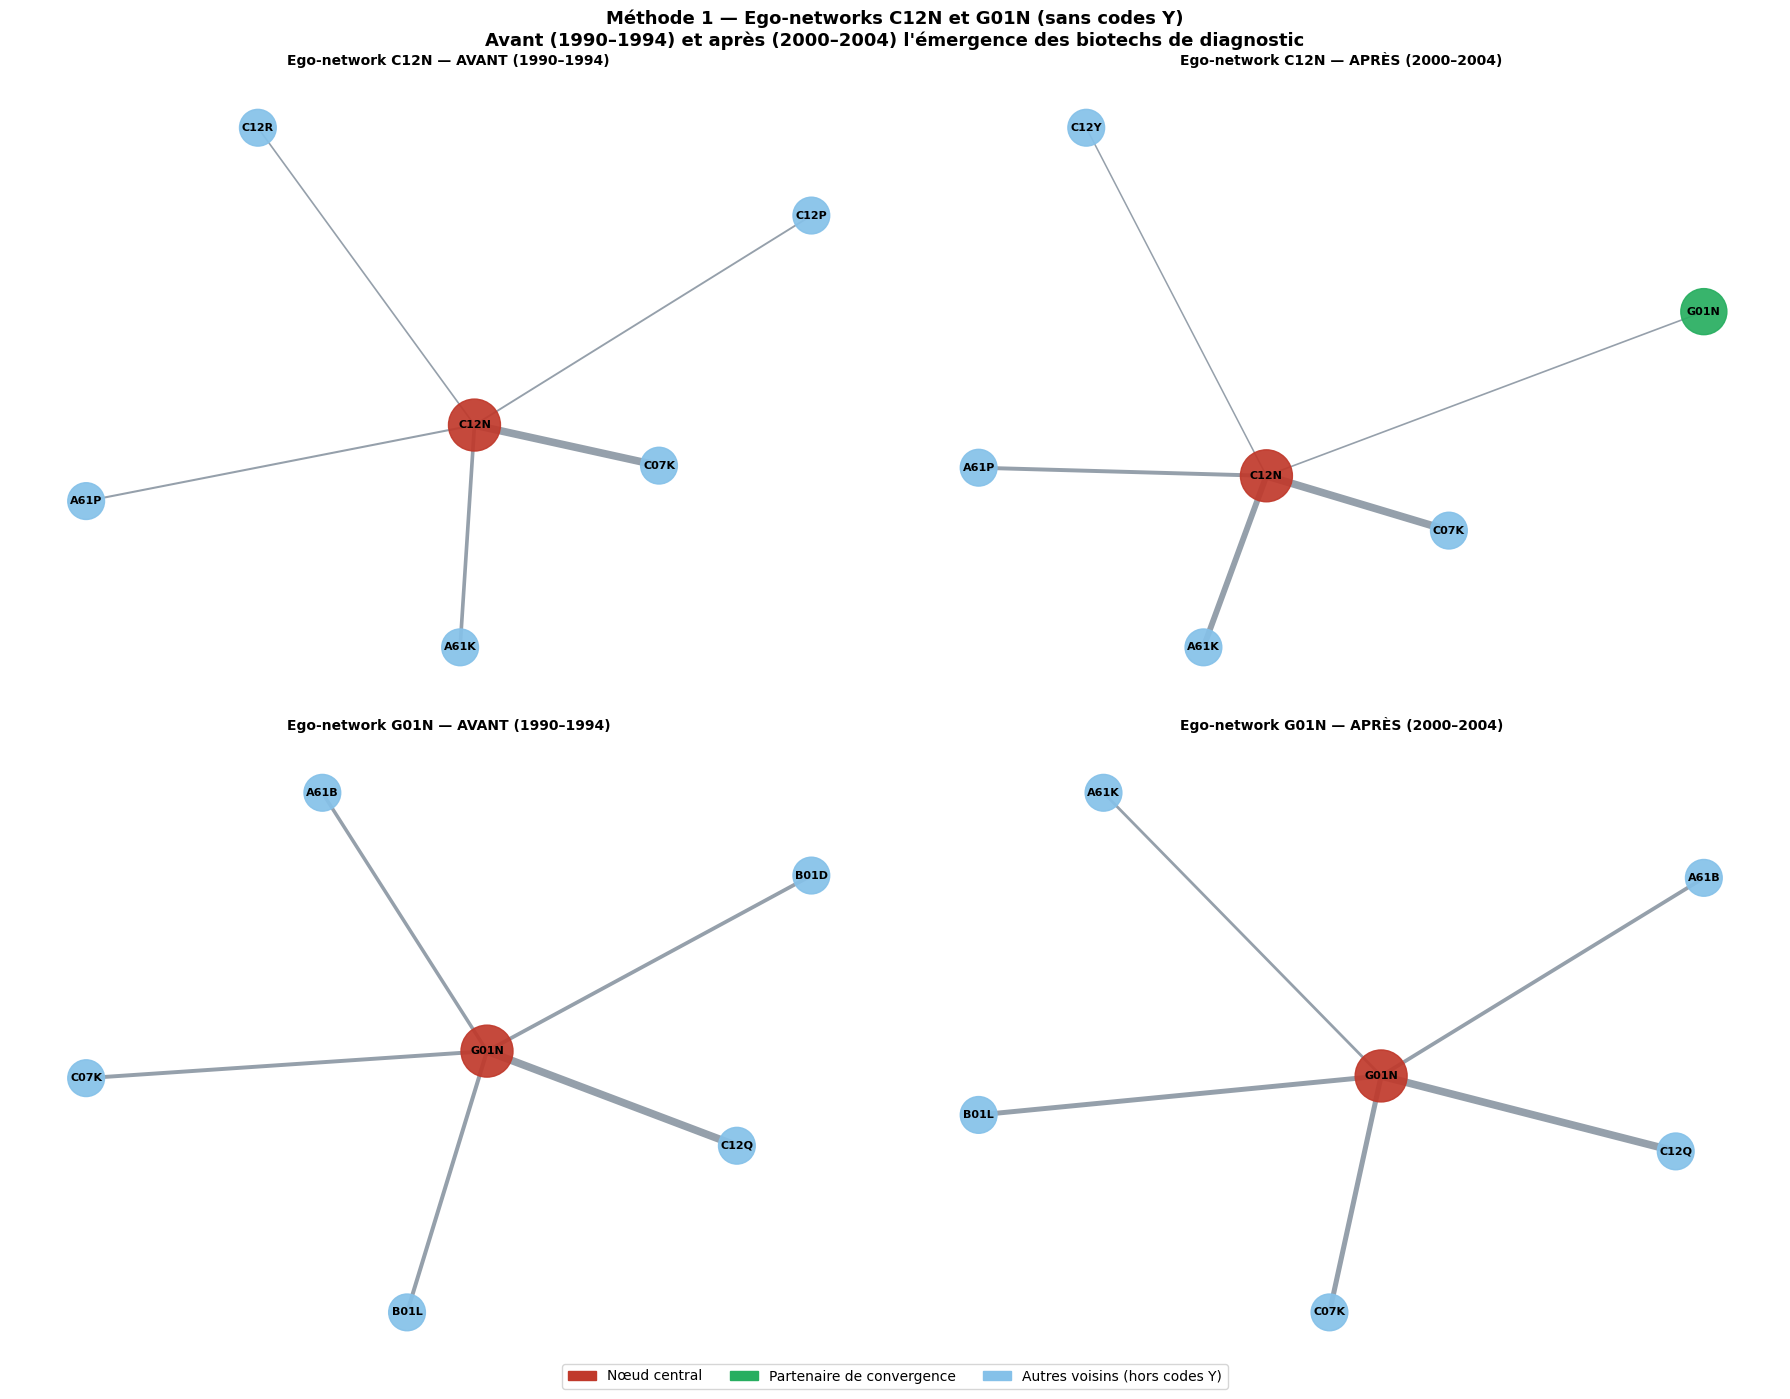

In [7]:
def build_ego_network_noY(df, cpc, year_start, year_end, n_neighbors=N_NEIGHBORS):
    df_w=df[(df['year']>=year_start)&(df['year']<=year_end)]
    df_w=df_w[df_w['cpc4'].apply(lambda x: cpc in x)]
    weights=defaultdict(float)
    for _,row in df_w.iterrows():
        codes=row['cpc4']; m=len(codes)
        if m<2: continue
        yr=row['year']
        w=(2.0/(m*(m-1)))*(N_mean/brevet_by_year.get(yr,N_mean))
        for c in codes:
            if c!=cpc and not c.startswith('Y'): weights[c]+=w
    top=sorted(weights.items(),key=lambda x:-x[1])[:n_neighbors]
    G=nx.Graph(); G.add_node(cpc)
    for neighbor,w in top: G.add_edge(cpc,neighbor,weight=w)
    return G

def plot_ego_network_v2(G, cpc, title, ax, other_cpc=None):
    pos=nx.spring_layout(G,seed=42,weight='weight',k=1.8)
    weights=[G[u][v]['weight'] for u,v in G.edges()]
    max_w=max(weights) if weights else 1
    node_colors,node_sizes=[],[]
    for n in G.nodes():
        if n==cpc: node_colors.append(C_RUPTURE); node_sizes.append(1400)
        elif n==other_cpc: node_colors.append('#27AE60'); node_sizes.append(1100)
        else: node_colors.append('#85C1E9'); node_sizes.append(700)
    nx.draw_networkx_nodes(G,pos,ax=ax,node_color=node_colors,
                           node_size=node_sizes,alpha=0.92)
    nx.draw_networkx_labels(G,pos,ax=ax,font_size=8,font_weight='bold')
    nx.draw_networkx_edges(G,pos,ax=ax,
                           width=[0.5+5*w/max_w for w in weights],
                           alpha=0.65,edge_color='#5D6D7E')
    ax.set_title(title,fontsize=10,fontweight='bold'); ax.axis('off')

# Fenêtres avant/après adaptées à l'émergence 1997
windows_bt={'avant':(1990,1994),'après':(2000,2004)}
ego_graphs={}
for cpc in [CPC_I,CPC_J]:
    ego_graphs[cpc]={}
    for label,(y0,y1) in windows_bt.items():
        ego_graphs[cpc][label]=build_ego_network_noY(df_raw,cpc,y0,y1)

fig,axes=plt.subplots(2,2,figsize=(18,14))
configs=[
    (CPC_I,'avant',CPC_J,f'Ego-network {CPC_I} — AVANT (1990–1994)',axes[0,0]),
    (CPC_I,'après',CPC_J,f'Ego-network {CPC_I} — APRÈS (2000–2004)',axes[0,1]),
    (CPC_J,'avant',CPC_I,f'Ego-network {CPC_J} — AVANT (1990–1994)',axes[1,0]),
    (CPC_J,'après',CPC_I,f'Ego-network {CPC_J} — APRÈS (2000–2004)',axes[1,1]),
]
for cpc,period,other,title,ax in configs:
    plot_ego_network_v2(ego_graphs[cpc][period],cpc,title,ax,other_cpc=other)
leg=[
    mpatches.Patch(color=C_RUPTURE,label='Nœud central'),
    mpatches.Patch(color='#27AE60',label='Partenaire de convergence'),
    mpatches.Patch(color='#85C1E9',label='Autres voisins (hors codes Y)'),
]
fig.legend(handles=leg,loc='lower center',ncol=3,fontsize=10,
           bbox_to_anchor=(0.5,-0.01))
plt.suptitle('Méthode 1 — Ego-networks C12N et G01N (sans codes Y)\n'
             'Avant (1990–1994) et après (2000–2004) l\'émergence des biotechs de diagnostic',
             fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('M1_ego_networks_biotech.png',dpi=150,bbox_inches='tight')
plt.show()

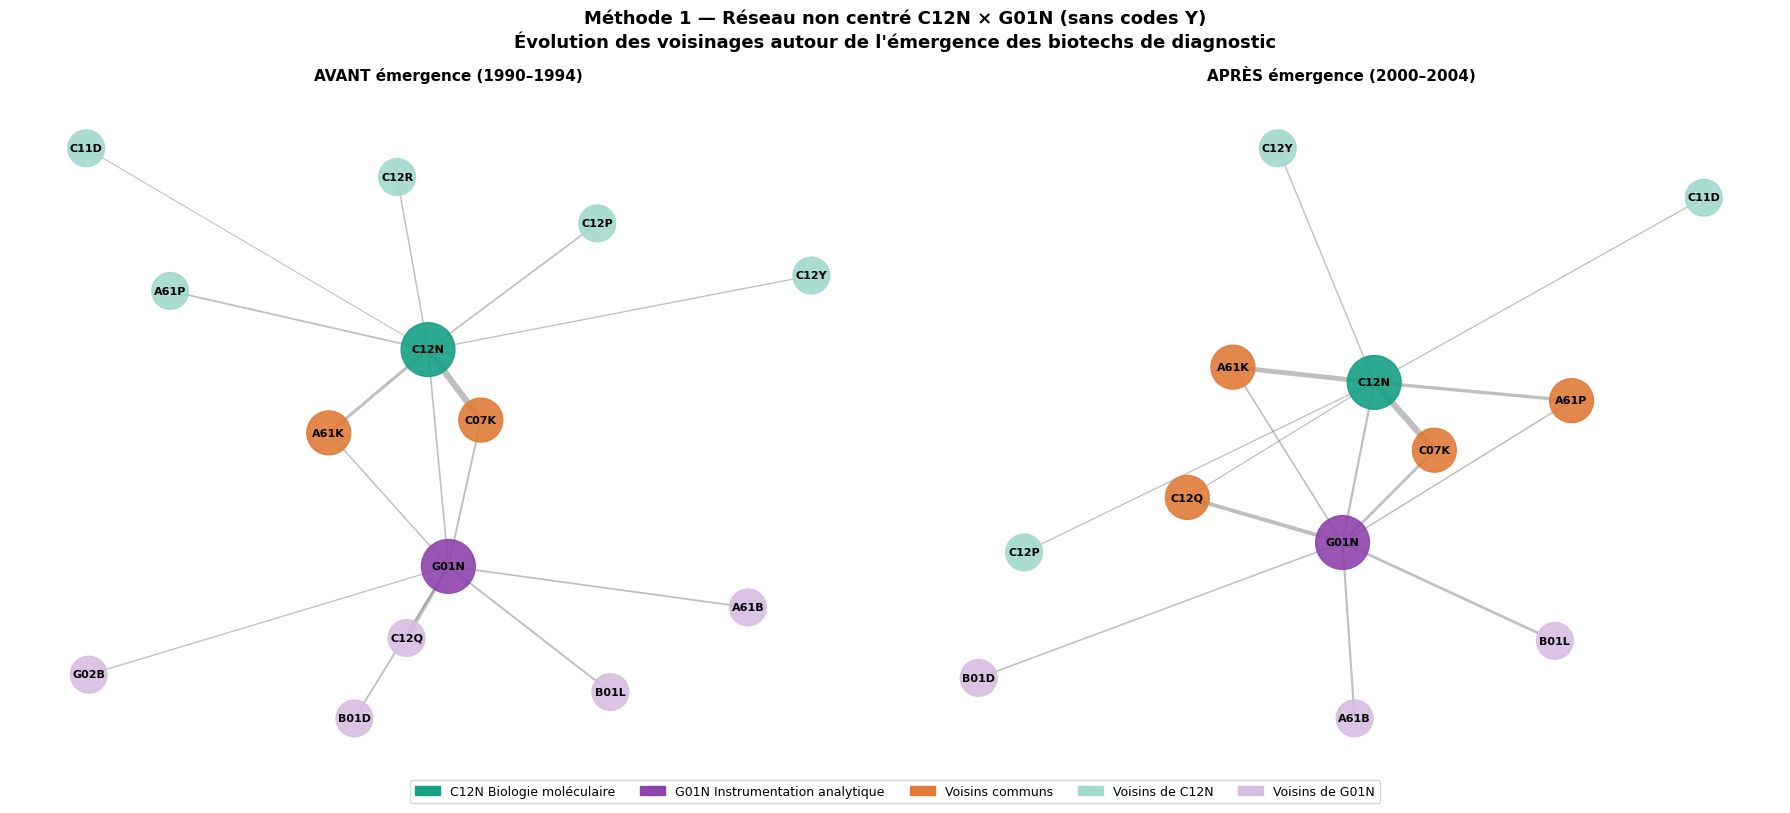

Voisins communs avant : 2 | après : 4
Nouveaux voisins communs : {'A61P', 'C12Q'}


In [8]:
def build_bipartite_noY(df, ci, cj, y0, y1, n=8):
    Gi=build_ego_network_noY(df,ci,y0,y1,n)
    Gj=build_ego_network_noY(df,cj,y0,y1,n)
    G=nx.Graph()
    for u,v,d in list(Gi.edges(data=True))+list(Gj.edges(data=True)):
        if G.has_edge(u,v): G[u][v]['weight']+=d['weight']
        else: G.add_edge(u,v,weight=d['weight'])
    ni=set(Gi.nodes())-{ci}; nj=set(Gj.nodes())-{cj}
    return G,ni,nj,ni&nj

def plot_bipartite_noY(G,ni,nj,common,ci,cj,title,ax):
    pos=nx.spring_layout(G,seed=42,weight='weight',k=2)
    weights=[G[u][v].get('weight',1) for u,v in G.edges()]
    max_w=max(weights) if weights else 1
    cmap={ci:C_I,cj:C_J}
    color_map,size_map=[],[]
    for n in G.nodes():
        if n in cmap: color_map.append(cmap[n]); size_map.append(1500)
        elif n in common: color_map.append(C_COMMUN); size_map.append(1000)
        elif n in ni: color_map.append('#A2D9CE'); size_map.append(700)
        else: color_map.append('#D7BDE2'); size_map.append(700)
    nx.draw_networkx_nodes(G,pos,ax=ax,node_color=color_map,
                           node_size=size_map,alpha=0.9)
    nx.draw_networkx_labels(G,pos,ax=ax,font_size=8,font_weight='bold')
    nx.draw_networkx_edges(G,pos,ax=ax,
                           width=[0.5+4*w/max_w for w in weights],
                           alpha=0.5,edge_color='gray')
    ax.set_title(title,fontsize=11,fontweight='bold'); ax.axis('off')

fig,axes=plt.subplots(1,2,figsize=(18,8))
G92,ni92,nj92,c92=build_bipartite_noY(df_raw,CPC_I,CPC_J,1990,1994)
G02,ni02,nj02,c02=build_bipartite_noY(df_raw,CPC_I,CPC_J,2000,2004)
plot_bipartite_noY(G92,ni92,nj92,c92,CPC_I,CPC_J,'AVANT émergence (1990–1994)',axes[0])
plot_bipartite_noY(G02,ni02,nj02,c02,CPC_I,CPC_J,'APRÈS émergence (2000–2004)',axes[1])
leg=[
    mpatches.Patch(color=C_I,label=f'{CPC_I} Biologie moléculaire'),
    mpatches.Patch(color=C_J,label=f'{CPC_J} Instrumentation analytique'),
    mpatches.Patch(color=C_COMMUN,label='Voisins communs'),
    mpatches.Patch(color='#A2D9CE',label=f'Voisins de {CPC_I}'),
    mpatches.Patch(color='#D7BDE2',label=f'Voisins de {CPC_J}'),
]
fig.legend(handles=leg,loc='lower center',ncol=5,fontsize=9,
           bbox_to_anchor=(0.5,-0.02))
plt.suptitle('Méthode 1 — Réseau non centré C12N × G01N (sans codes Y)\n'
             'Évolution des voisinages autour de l\'émergence des biotechs de diagnostic',
             fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('M1_reseau_non_centre_biotech.png',dpi=150,bbox_inches='tight')
plt.show()
print(f'Voisins communs avant : {len(c92)} | après : {len(c02)}')
print(f'Nouveaux voisins communs : {c02-c92}')

---
# MÉTHODE 2 — Clustering dynamique

In [9]:
def build_cooc_window(df, t, window=WINDOW):
    df_w=df[(df['year']>=t-window//2)&(df['year']<=t+window//2)]
    counter=Counter()
    for codes in df_w['cpc4']:
        for ci,cj in itertools.combinations(sorted(set(codes)),2):
            counter[(ci,cj)]+=1; counter[(cj,ci)]+=1
    cooc=pd.DataFrame([(i,j,c) for (i,j),c in counter.items()],
                      columns=['cpc_i','cpc_j','count'])
    if len(cooc)==0: return pd.DataFrame()
    rs=cooc.groupby('cpc_i')['count'].sum().rename('row_sum')
    cooc=cooc.join(rs,on='cpc_i')
    cooc['M_ij']=cooc['count']/cooc['row_sum']
    return cooc

def align_labels(labels_prev,labels_curr,k):
    confusion=np.zeros((k,k),dtype=int)
    for p,c in zip(labels_prev,labels_curr):
        if 0<=p<k and 0<=c<k: confusion[p,c]+=1
    row_ind,col_ind=linear_sum_assignment(-confusion)
    mapping={col:row for row,col in zip(row_ind,col_ind)}
    return np.array([mapping.get(l,l) for l in labels_curr])

print('Clustering dynamique...')
pca_obj=PCA(n_components=N_PCA,random_state=0)
km_obj=KMeans(n_clusters=K_CLUSTERS,random_state=42,n_init=10)
cluster_records=[]; prev_labels=None; prev_nodes=None

for t in range(YEAR_START,YEAR_END+1):
    cooc=build_cooc_window(df_raw,t)
    if len(cooc)==0: continue
    M=cooc.pivot(index='cpc_i',columns='cpc_j',values='M_ij').fillna(0)
    if M.shape[0]<N_PCA+1: continue
    labels_raw=km_obj.fit_predict(pca_obj.fit_transform(M))
    if prev_labels is not None and prev_nodes is not None:
        common_nodes=list(set(M.index)&set(prev_nodes))
        if len(common_nodes)>K_CLUSTERS:
            prev_l=np.array([prev_labels[list(prev_nodes).index(n)]
                             for n in common_nodes if n in prev_nodes])
            curr_l=np.array([labels_raw[list(M.index).index(n)]
                             for n in common_nodes if n in M.index])
            if len(prev_l)==len(curr_l) and len(prev_l)>0:
                labels_raw=align_labels(prev_l,labels_raw,K_CLUSTERS)
    prev_labels=labels_raw; prev_nodes=list(M.index)
    for cpc,cl in zip(M.index,labels_raw):
        cluster_records.append({'year':t,'cpc4':cpc,'cluster':int(cl)})

cluster_df=pd.DataFrame(cluster_records)
print(f'  {cluster_df["year"].nunique()} années')

Clustering dynamique...
  35 années


In [10]:
cl_sorted=cluster_df.sort_values(['cpc4','year'])
transitions=[]
for cpc,sub in cl_sorted.groupby('cpc4'):
    sub=sub.sort_values('year')
    for i in range(len(sub)-1):
        if sub.iloc[i+1]['year']-sub.iloc[i]['year']==1:
            transitions.append({
                'cpc':cpc,'year_t':sub.iloc[i]['year'],
                'year_t1':sub.iloc[i+1]['year'],
                'cluster_t':sub.iloc[i]['cluster'],
                'cluster_t1':sub.iloc[i+1]['cluster']
            })
trans_df=pd.DataFrame(transitions)

def entropy_fn(p):
    p=p[p>0]; return -np.sum(p*np.log(p))

inflow=(trans_df.groupby(['year_t1','cluster_t1'])['cluster_t']
        .value_counts(normalize=True).rename('p').reset_index())
H_in=(inflow.groupby(['year_t1','cluster_t1'])['p']
      .apply(entropy_fn).reset_index(name='H_in'))
persist=(trans_df.groupby(['year_t','cluster_t'])
         .apply(lambda x: np.mean(x['cluster_t1']==x['cluster_t']))
         .reset_index(name='persistence'))
absorb=(H_in.merge(persist,left_on=['year_t1','cluster_t1'],
                   right_on=['year_t','cluster_t'],how='left')
        .drop(columns=['year_t','cluster_t'])
        .rename(columns={'year_t1':'year','cluster_t1':'cluster'}))
absorb['absorption']=absorb['H_in']*absorb['persistence'].fillna(0)

cl_lkp=cluster_df.set_index(['cpc4','year'])['cluster'].to_dict()
traj=[]
for t in range(YEAR_START,YEAR_END+1):
    ci=cl_lkp.get((CPC_I,t)); cj=cl_lkp.get((CPC_J,t))
    if ci is None or cj is None: continue
    abs_row=absorb[(absorb['year']==t)&(absorb['cluster']==ci)]
    traj.append({
        'year':t,'cluster_I':ci,'cluster_J':cj,'same':ci==cj,
        'H_in':abs_row['H_in'].values[0] if len(abs_row)>0 else 0,
        'persistence':abs_row['persistence'].values[0] if len(abs_row)>0 else 0,
        'absorption':abs_row['absorption'].values[0] if len(abs_row)>0 else 0,
    })
df_traj=pd.DataFrame(traj)

display(df_traj[df_traj['year'].isin([1992,1995,1997,2000,2003,2007,2012,2018])]
        [['year','cluster_I','cluster_J','same','H_in','persistence','absorption']])

,year,cluster_I,cluster_J,same,H_in,persistence,absorption
4,1992,6,0,False,-0.000000,0.971429,-0.000000
7,1995,3,1,False,0.119247,0.948718,0.113132
9,1997,3,1,False,-0.000000,0.000000,-0.000000
12,2000,1,6,False,-0.000000,0.000000,-0.000000
15,2003,6,0,False,-0.000000,0.000000,-0.000000
19,2007,6,6,True,0.106566,0.044444,0.004736
24,2012,8,8,True,-0.000000,1.000000,-0.000000
30,2018,1,1,True,0.664528,0.000000,0.000000


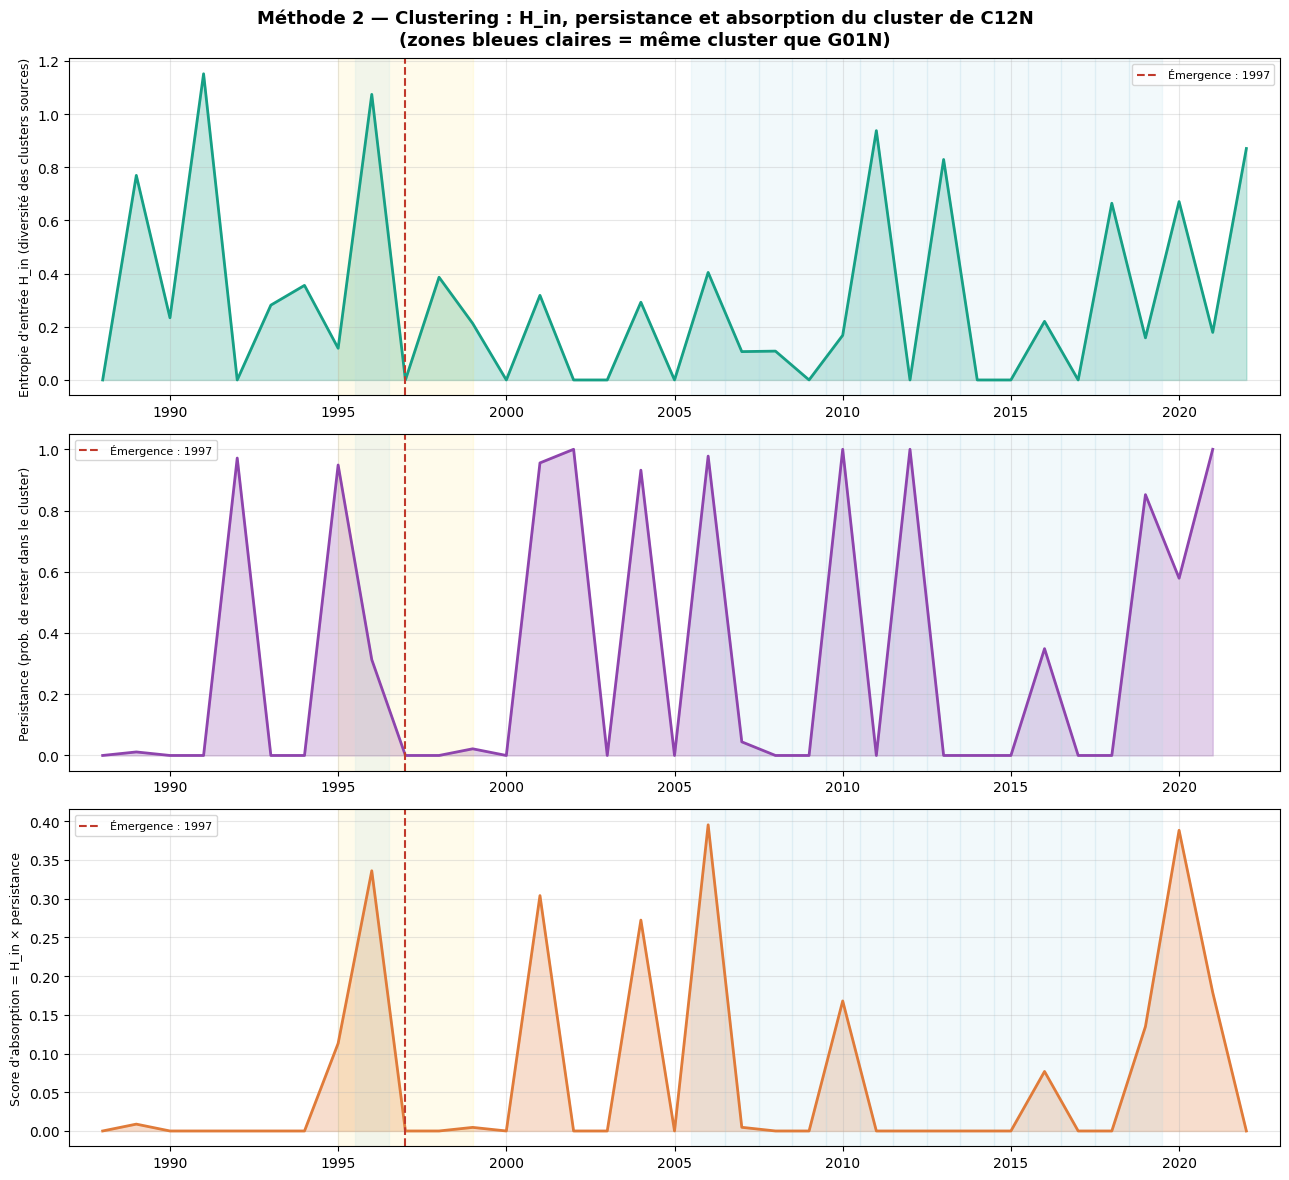

In [11]:
fig,axes=plt.subplots(3,1,figsize=(13,12))
for ax,col,label,color in [
    (axes[0],'H_in','Entropie d\'entrée H_in (diversité des clusters sources)',C_I),
    (axes[1],'persistence','Persistance (prob. de rester dans le cluster)',C_J),
    (axes[2],'absorption','Score d\'absorption = H_in × persistance',C_COMMUN)
]:
    ax.fill_between(df_traj['year'],0,df_traj[col],alpha=0.25,color=color)
    ax.plot(df_traj['year'],df_traj[col],color=color,lw=2)
    ax.axvline(YEAR_EMERGE,color=C_RUPTURE,ls='--',lw=1.5,
               label=f'Émergence : {YEAR_EMERGE}')
    ax.axvspan(YEAR_EMERGE-2,YEAR_EMERGE+2,alpha=0.08,color='gold')
    for yr in df_traj[df_traj['same']]['year']:
        ax.axvspan(yr-0.5,yr+0.5,alpha=0.15,color='lightblue')
    ax.set_ylabel(label,fontsize=9)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlim(YEAR_START-1,YEAR_END+1)
plt.suptitle('Méthode 2 — Clustering : H_in, persistance et absorption du cluster de C12N\n'
             '(zones bleues claires = même cluster que G01N)',
             fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('M2_absorption_biotech.png',dpi=150,bbox_inches='tight')
plt.show()

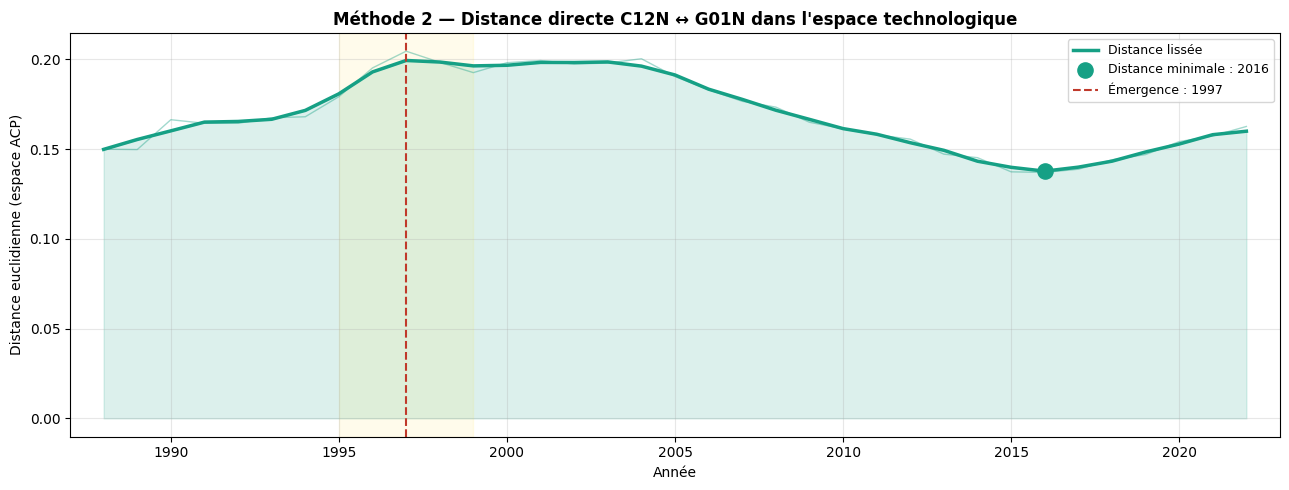

In [12]:
pca_dist=PCA(n_components=N_PCA,random_state=0)
dist_records=[]
for t in range(YEAR_START,YEAR_END+1):
    cooc=build_cooc_window(df_raw,t)
    if len(cooc)==0: continue
    M=cooc.pivot(index='cpc_i',columns='cpc_j',values='M_ij').fillna(0)
    if M.shape[0]<N_PCA+1: continue
    if CPC_I not in M.index or CPC_J not in M.index: continue
    M_pca=pca_dist.fit_transform(M)
    idx_i=list(M.index).index(CPC_I)
    idx_j=list(M.index).index(CPC_J)
    dist_records.append({'year':t,
                         'dist_direct':np.linalg.norm(M_pca[idx_i]-M_pca[idx_j])})
df_dist=pd.DataFrame(dist_records)

fig,ax=plt.subplots(figsize=(13,5))
y=df_dist['dist_direct'].values; ys=smooth(y)
ax.fill_between(df_dist['year'],0,ys,alpha=0.15,color=C_I)
ax.plot(df_dist['year'],y,color=C_I,lw=1,alpha=0.4)
ax.plot(df_dist['year'],ys,color=C_I,lw=2.5,label='Distance lissée')
idx_min=np.nanargmin(ys)
ax.scatter([df_dist['year'].values[idx_min]],[ys[idx_min]],
           color=C_I,s=120,zorder=5,
           label=f'Distance minimale : {df_dist["year"].values[idx_min]}')
ax.axvline(YEAR_EMERGE,color=C_RUPTURE,ls='--',lw=1.5,
           label=f'Émergence : {YEAR_EMERGE}')
ax.axvspan(YEAR_EMERGE-2,YEAR_EMERGE+2,alpha=0.08,color='gold')
ax.set_xlabel('Année'); ax.set_ylabel('Distance euclidienne (espace ACP)')
ax.set_title('Méthode 2 — Distance directe C12N ↔ G01N dans l\'espace technologique',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlim(YEAR_START-1,YEAR_END+1)
plt.tight_layout()
plt.savefig('M2_distance_biotech.png',dpi=150,bbox_inches='tight')
plt.show()

---
# MÉTHODE 3 — Séries temporelles

TESTS ADF :
  C12N niveaux              : p=0.0090 ✅
  G01N niveaux              : p=0.9973 ❌
  C12N diff.1               : p=0.1042 ❌
  G01N diff.1               : p=0.0012 ✅
  C12N diff.2               : p=0.8666 ❌
  G01N diff.2               : p=0.0000 ✅


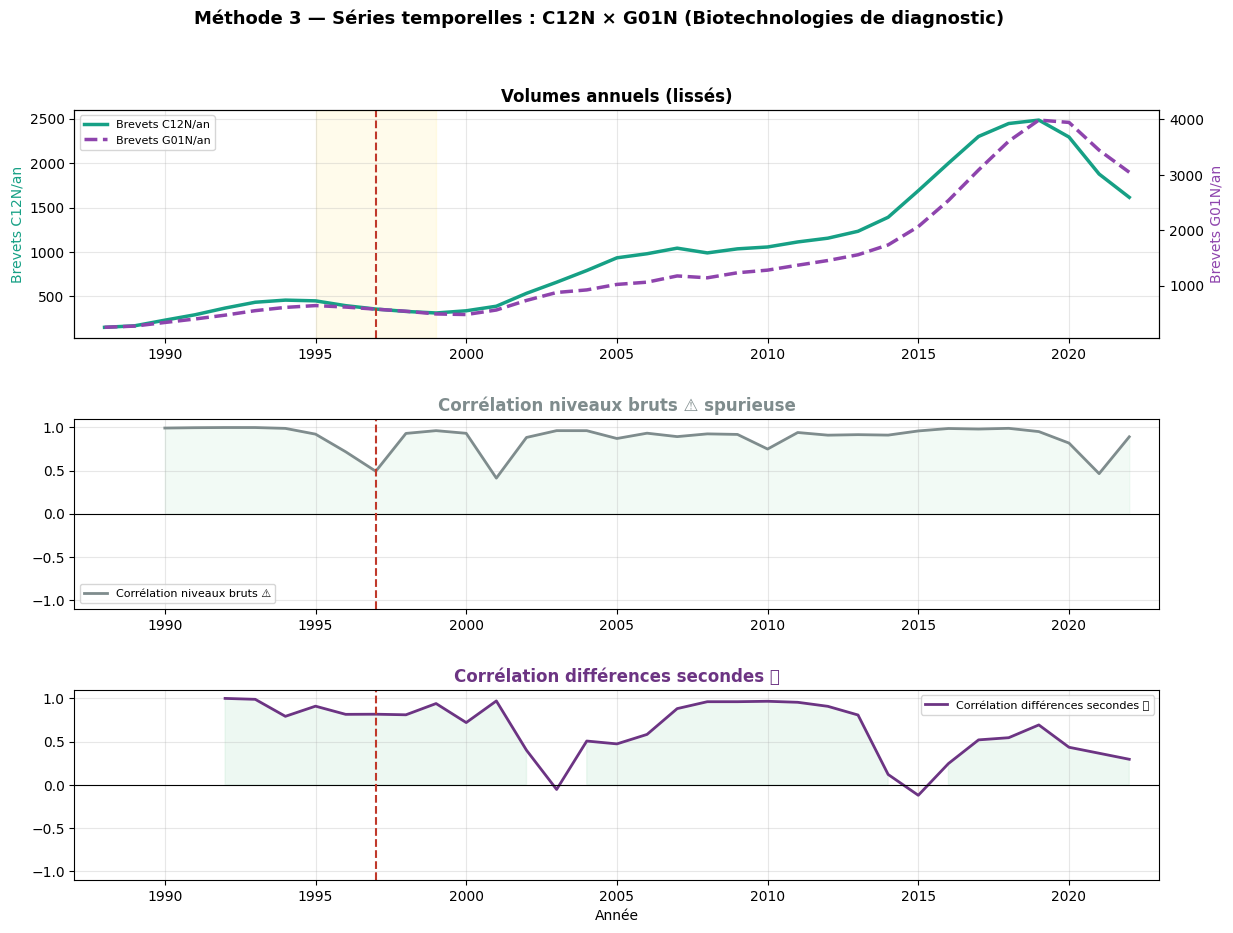

In [13]:
cooc_direct=[]
for t in range(YEAR_START,YEAR_END+1):
    n_i=n_j=n_ij=0
    for codes in df_raw[df_raw['year']==t]['cpc4']:
        hi=CPC_I in codes; hj=CPC_J in codes
        if hi: n_i+=1
        if hj: n_j+=1
        if hi and hj: n_ij+=1
    cooc_direct.append({'year':t,'n_I':n_i,'n_J':n_j,'n_both':n_ij})

df_cooc=pd.DataFrame(cooc_direct)
serie_I=df_cooc.set_index('year')['n_I']
serie_J=df_cooc.set_index('year')['n_J']
dI=serie_I.diff().dropna(); dJ=serie_J.diff().dropna()
d2I=serie_I.diff().diff().dropna(); d2J=serie_J.diff().diff().dropna()

print('TESTS ADF :')
for name,serie in [
    (f'{CPC_I} niveaux',serie_I),(f'{CPC_J} niveaux',serie_J),
    (f'{CPC_I} diff.1',dI),(f'{CPC_J} diff.1',dJ),
    (f'{CPC_I} diff.2',d2I),(f'{CPC_J} diff.2',d2J),
]:
    stat,pval,*_=adfuller(serie,autolag='AIC')
    v='✅' if pval<0.05 else '❌'
    print(f'  {name:25s} : p={pval:.4f} {v}')

corr_niveaux=serie_I.rolling(CORR_WINDOW,min_periods=3).corr(serie_J)
corr_diff2=d2I.rolling(CORR_WINDOW,min_periods=3).corr(d2J)

fig=plt.figure(figsize=(14,10))
gs=gridspec.GridSpec(3,1,height_ratios=[1.2,1,1],hspace=0.4)

ax1=fig.add_subplot(gs[0]); ax1b=ax1.twinx()
ax1.plot(serie_I.index,smooth(serie_I.values),color=C_I,lw=2.5,
         label=f'Brevets {CPC_I}/an')
ax1b.plot(serie_J.index,smooth(serie_J.values),color=C_J,lw=2.5,ls='--',
          label=f'Brevets {CPC_J}/an')
ax1.axvline(YEAR_EMERGE,color=C_RUPTURE,ls='--',lw=1.5)
ax1.axvspan(YEAR_EMERGE-2,YEAR_EMERGE+2,alpha=0.08,color='gold')
ax1.set_ylabel(f'Brevets {CPC_I}/an',color=C_I)
ax1b.set_ylabel(f'Brevets {CPC_J}/an',color=C_J)
ax1.set_title('Volumes annuels (lissés)',fontweight='bold')
l1,lb1=ax1.get_legend_handles_labels()
l2,lb2=ax1b.get_legend_handles_labels()
ax1.legend(l1+l2,lb1+lb2,fontsize=8); ax1.grid(alpha=0.3)

ax2=fig.add_subplot(gs[1])
ax2.plot(corr_niveaux.index,corr_niveaux.values,color='#7F8C8D',lw=2,
         label='Corrélation niveaux bruts ⚠️')
ax2.fill_between(corr_niveaux.index,0,corr_niveaux.values,
                 where=corr_niveaux.values>=0,alpha=0.15,color=C_POS)
ax2.axhline(0,color='black',lw=0.8)
ax2.axvline(YEAR_EMERGE,color=C_RUPTURE,ls='--',lw=1.5)
ax2.set_ylim(-1.1,1.1)
ax2.set_title('Corrélation niveaux bruts ⚠️ spurieuse',fontweight='bold',color='#7F8C8D')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

ax3=fig.add_subplot(gs[2])
ax3.plot(corr_diff2.index,corr_diff2.values,color='#6C3483',lw=2,
         label='Corrélation différences secondes ✅')
ax3.fill_between(corr_diff2.index,0,corr_diff2.values,
                 where=corr_diff2.values>=0,alpha=0.2,color=C_POS)
ax3.fill_between(corr_diff2.index,0,corr_diff2.values,
                 where=corr_diff2.values<0,alpha=0.2,color=C_NEG)
ax3.axhline(0,color='black',lw=0.8)
ax3.axvline(YEAR_EMERGE,color=C_RUPTURE,ls='--',lw=1.5)
ax3.set_ylim(-1.1,1.1)
ax3.set_xlabel('Année')
ax3.set_title('Corrélation différences secondes ✅',fontweight='bold',color='#6C3483')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

for ax in [ax1,ax2,ax3]: ax.set_xlim(YEAR_START-1,YEAR_END+1)
plt.suptitle('Méthode 3 — Séries temporelles : C12N × G01N (Biotechnologies de diagnostic)',
             fontsize=13,fontweight='bold')
plt.savefig('M3_correlation_biotech.png',dpi=150,bbox_inches='tight')
plt.show()

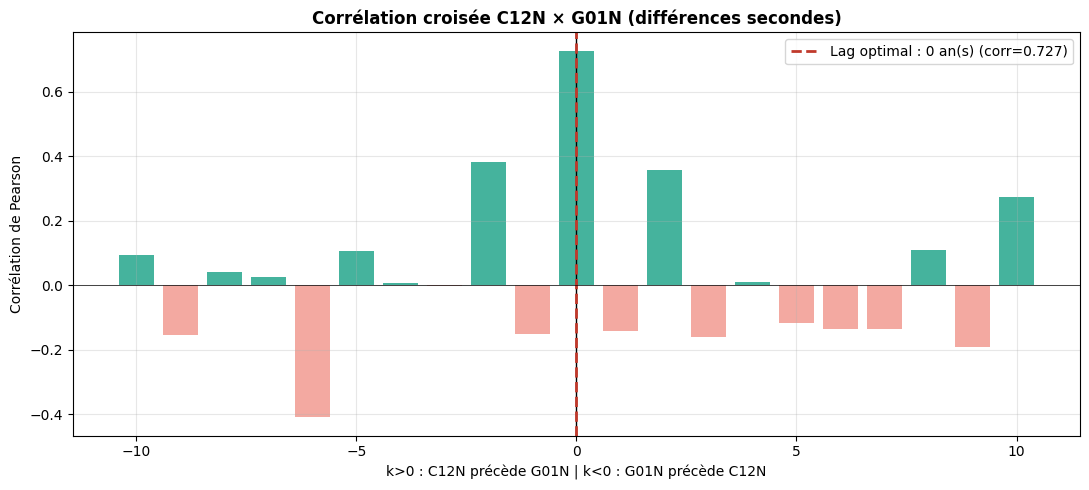


Granger C12N → G01N :
  Lag 1 : p=0.5623 
  Lag 2 : p=0.0835 
  Lag 3 : p=0.0200 ✅
  Lag 4 : p=0.0402 ✅
  Lag 5 : p=0.0021 ✅

Granger G01N → C12N (inverse) :
  Lag 1 : p=0.2011 
  Lag 2 : p=0.6758 
  Lag 3 : p=0.5851 
  Lag 4 : p=0.7507 
  Lag 5 : p=0.3985 


In [14]:
max_lag=10; lags=range(-max_lag,max_lag+1); corrs=[]
for lag in lags:
    if lag>=0:
        s1=d2I.iloc[lag:].values; s2=d2J.iloc[:len(s1)].values
    else:
        s2=d2J.iloc[-lag:].values; s1=d2I.iloc[:len(s2)].values
    corrs.append(pearsonr(s1,s2)[0] if len(s1)>5 else np.nan)

best_lag=list(lags)[np.nanargmax(corrs)]
fig,ax=plt.subplots(figsize=(11,5))
ax.bar(lags,corrs,color=[C_I if c>0 else C_NEG for c in corrs],alpha=0.8)
ax.axvline(0,color='black',lw=1)
ax.axvline(best_lag,color=C_RUPTURE,lw=2,ls='--',
           label=f'Lag optimal : {best_lag} an(s) (corr={np.nanmax(corrs):.3f})')
ax.axhline(0,color='black',lw=0.5)
ax.set_xlabel('k>0 : C12N précède G01N | k<0 : G01N précède C12N')
ax.set_ylabel('Corrélation de Pearson')
ax.set_title('Corrélation croisée C12N × G01N (différences secondes)',fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('M3_corr_croisee_biotech.png',dpi=150,bbox_inches='tight')
plt.show()

print('\nGranger C12N → G01N :')
df_gr=pd.DataFrame({'J':d2J,'I':d2I}).dropna()
res=grangercausalitytests(df_gr[['J','I']],maxlag=5,verbose=False)
for lag,r in res.items():
    p=r[0]['ssr_ftest'][1]
    print(f'  Lag {lag} : p={p:.4f} {"✅" if p<0.05 else ""}')

print('\nGranger G01N → C12N (inverse) :')
res_inv=grangercausalitytests(df_gr[['I','J']],maxlag=5,verbose=False)
for lag,r in res_inv.items():
    p=r[0]['ssr_ftest'][1]
    print(f'  Lag {lag} : p={p:.4f} {"✅" if p<0.05 else ""}')

---
# MÉTHODE 4 — Jaccard + Probabilités conditionnelles

In [15]:
def compute_jaccard_full(df, ci, cj, window=WINDOW):
    records=[]
    for t in range(YEAR_START,YEAR_END+1):
        df_w=df[(df['year']>=t-window//2)&(df['year']<=t+window//2)]
        n_i=n_j=n_ij=0
        for codes in df_w['cpc4']:
            hi=ci in codes; hj=cj in codes
            if hi: n_i+=1
            if hj: n_j+=1
            if hi and hj: n_ij+=1
        union=n_i+n_j-n_ij
        records.append({
            'year':t,'jaccard':n_ij/union if union>0 else 0.,
            'p_j_given_i':n_ij/n_i if n_i>0 else 0.,
            'p_i_given_j':n_ij/n_j if n_j>0 else 0.,
        })
    return pd.DataFrame(records)

df_jac=compute_jaccard_full(df_raw,CPC_I,CPC_J)

print('Avant émergence :')
display(df_jac[df_jac['year']<YEAR_EMERGE]
        [['jaccard','p_j_given_i','p_i_given_j']].describe().round(4))
print('Après émergence :')
display(df_jac[df_jac['year']>=YEAR_EMERGE]
        [['jaccard','p_j_given_i','p_i_given_j']].describe().round(4))

Avant émergence :


,jaccard,p_j_given_i,p_i_given_j
count,9.0000,9.0000,9.0000
mean,0.0379,0.0882,0.0625
std,0.0045,0.0106,0.0074
min,0.0330,0.0773,0.0542
25%,0.0343,0.0818,0.0549
50%,0.0379,0.0852,0.0645
75%,0.0404,0.0915,0.0675
max,0.0451,0.1078,0.0723


Après émergence :


,jaccard,p_j_given_i,p_i_given_j
count,26.0000,26.0000,26.0000
mean,0.0642,0.1425,0.1053
std,0.0114,0.0272,0.0188
min,0.0462,0.1007,0.0724
25%,0.0504,0.1180,0.0835
50%,0.0705,0.1446,0.1095
75%,0.0733,0.1646,0.1207
max,0.0773,0.1884,0.1277


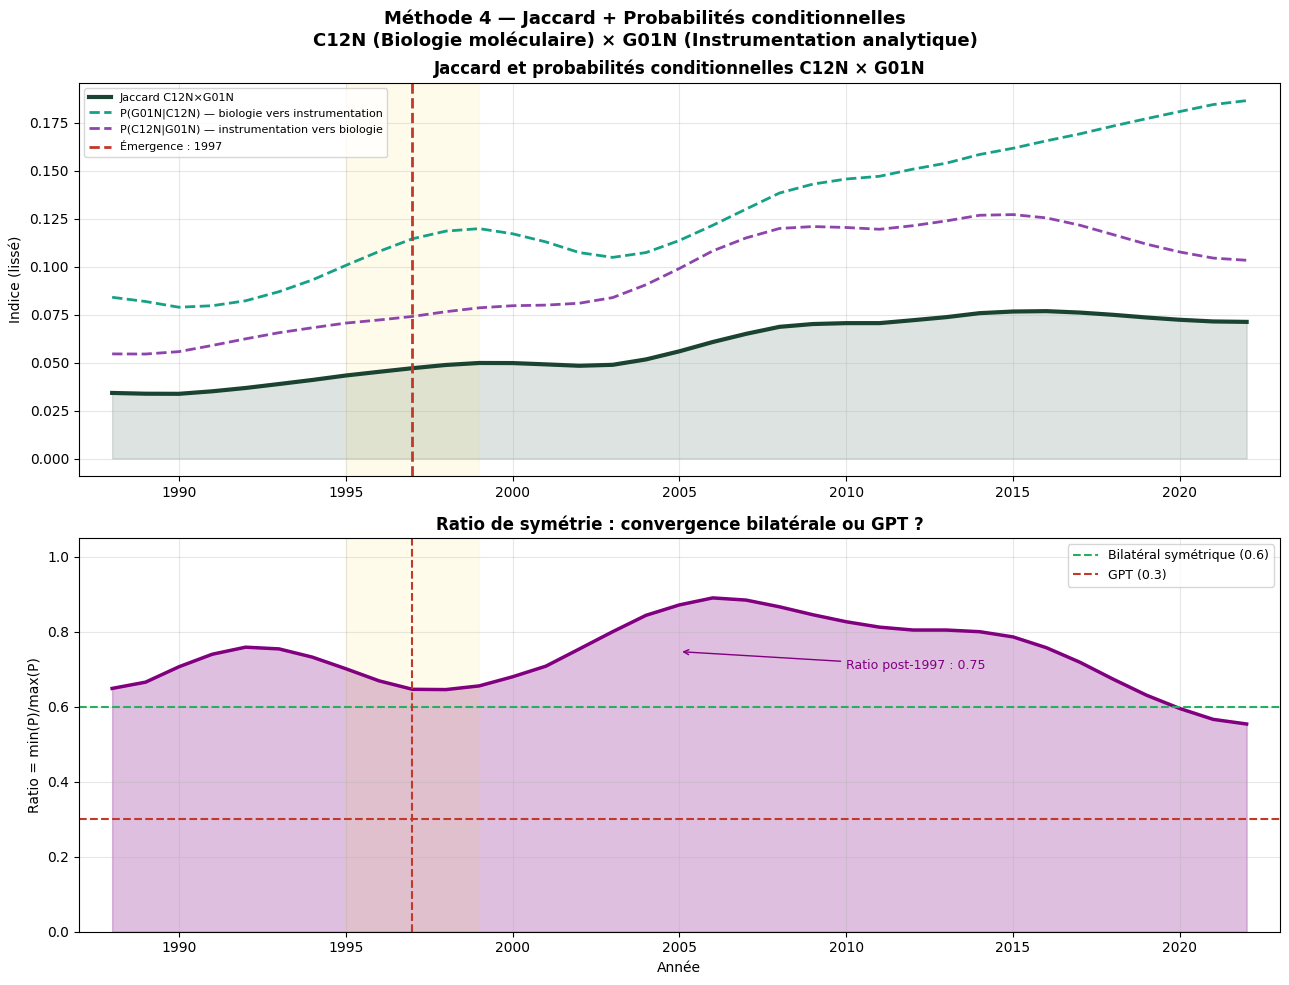

P(G01N|C12N) post-1997 = 0.1425
P(C12N|G01N) post-1997 = 0.1053
Ratio de symétrie post-1997 = 0.747
→ ✅ Convergence bilatérale SYMÉTRIQUE


In [16]:
x=df_jac['year'].values
jac=smooth(df_jac['jaccard'].values)
pji=smooth(df_jac['p_j_given_i'].values)
pij=smooth(df_jac['p_i_given_j'].values)
ratio=np.where(np.maximum(pji,pij)>0.001,
               np.minimum(pji,pij)/np.maximum(pji,pij),np.nan)

fig,axes=plt.subplots(2,1,figsize=(13,10))
ax=axes[0]
ax.fill_between(x,0,jac,alpha=0.15,color=C_JACCARD)
ax.plot(x,jac,color=C_JACCARD,lw=3,label=f'Jaccard {CPC_I}×{CPC_J}')
ax.plot(x,pji,color=C_I,lw=2,ls='--',
        label=f'P({CPC_J}|{CPC_I}) — biologie vers instrumentation')
ax.plot(x,pij,color=C_J,lw=2,ls='--',
        label=f'P({CPC_I}|{CPC_J}) — instrumentation vers biologie')
ax.axvline(YEAR_EMERGE,color=C_RUPTURE,ls='--',lw=2,
           label=f'Émergence : {YEAR_EMERGE}')
ax.axvspan(YEAR_EMERGE-2,YEAR_EMERGE+2,alpha=0.08,color='gold')
ax.set_ylabel('Indice (lissé)')
ax.set_title(f'Jaccard et probabilités conditionnelles {CPC_I} × {CPC_J}',fontweight='bold')
ax.legend(fontsize=8,loc='upper left'); ax.grid(alpha=0.3)

ax2=axes[1]
ax2.fill_between(x,0,ratio,alpha=0.25,color='purple')
ax2.plot(x,ratio,color='purple',lw=2.5)
ax2.axhline(0.6,color='#27AE60',ls='--',lw=1.5,label='Bilatéral symétrique (0.6)')
ax2.axhline(0.3,color=C_RUPTURE,ls='--',lw=1.5,label='GPT (0.3)')
ax2.axvline(YEAR_EMERGE,color=C_RUPTURE,ls='--',lw=1.5)
ax2.axvspan(YEAR_EMERGE-2,YEAR_EMERGE+2,alpha=0.08,color='gold')
ratio_post=np.nanmean(ratio[x>=YEAR_EMERGE])
ax2.annotate(f'Ratio post-{YEAR_EMERGE} : {ratio_post:.2f}',
             xy=(2005,ratio_post),xytext=(2010,0.7),fontsize=9,color='purple',
             arrowprops=dict(arrowstyle='->',color='purple'))
ax2.set_ylim(0,1.05)
ax2.set_ylabel('Ratio = min(P)/max(P)')
ax2.set_xlabel('Année')
ax2.set_title('Ratio de symétrie : convergence bilatérale ou GPT ?',fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

for ax in axes: ax.set_xlim(YEAR_START-1,YEAR_END+1)
plt.suptitle('Méthode 4 — Jaccard + Probabilités conditionnelles\n'
             'C12N (Biologie moléculaire) × G01N (Instrumentation analytique)',
             fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('M4_jaccard_biotech.png',dpi=150,bbox_inches='tight')
plt.show()

print(f'P({CPC_J}|{CPC_I}) post-{YEAR_EMERGE} = {np.mean(df_jac[df_jac["year"]>=YEAR_EMERGE]["p_j_given_i"]):.4f}')
print(f'P({CPC_I}|{CPC_J}) post-{YEAR_EMERGE} = {np.mean(df_jac[df_jac["year"]>=YEAR_EMERGE]["p_i_given_j"]):.4f}')
print(f'Ratio de symétrie post-{YEAR_EMERGE} = {ratio_post:.3f}')
if ratio_post>0.6: print('→ ✅ Convergence bilatérale SYMÉTRIQUE')
elif ratio_post>0.3: print('→ ✅ Convergence bilatérale ASYMÉTRIQUE')
else: print('→ ⚠️ Intégration unilatérale GPT')

---
# SYNTHÈSE

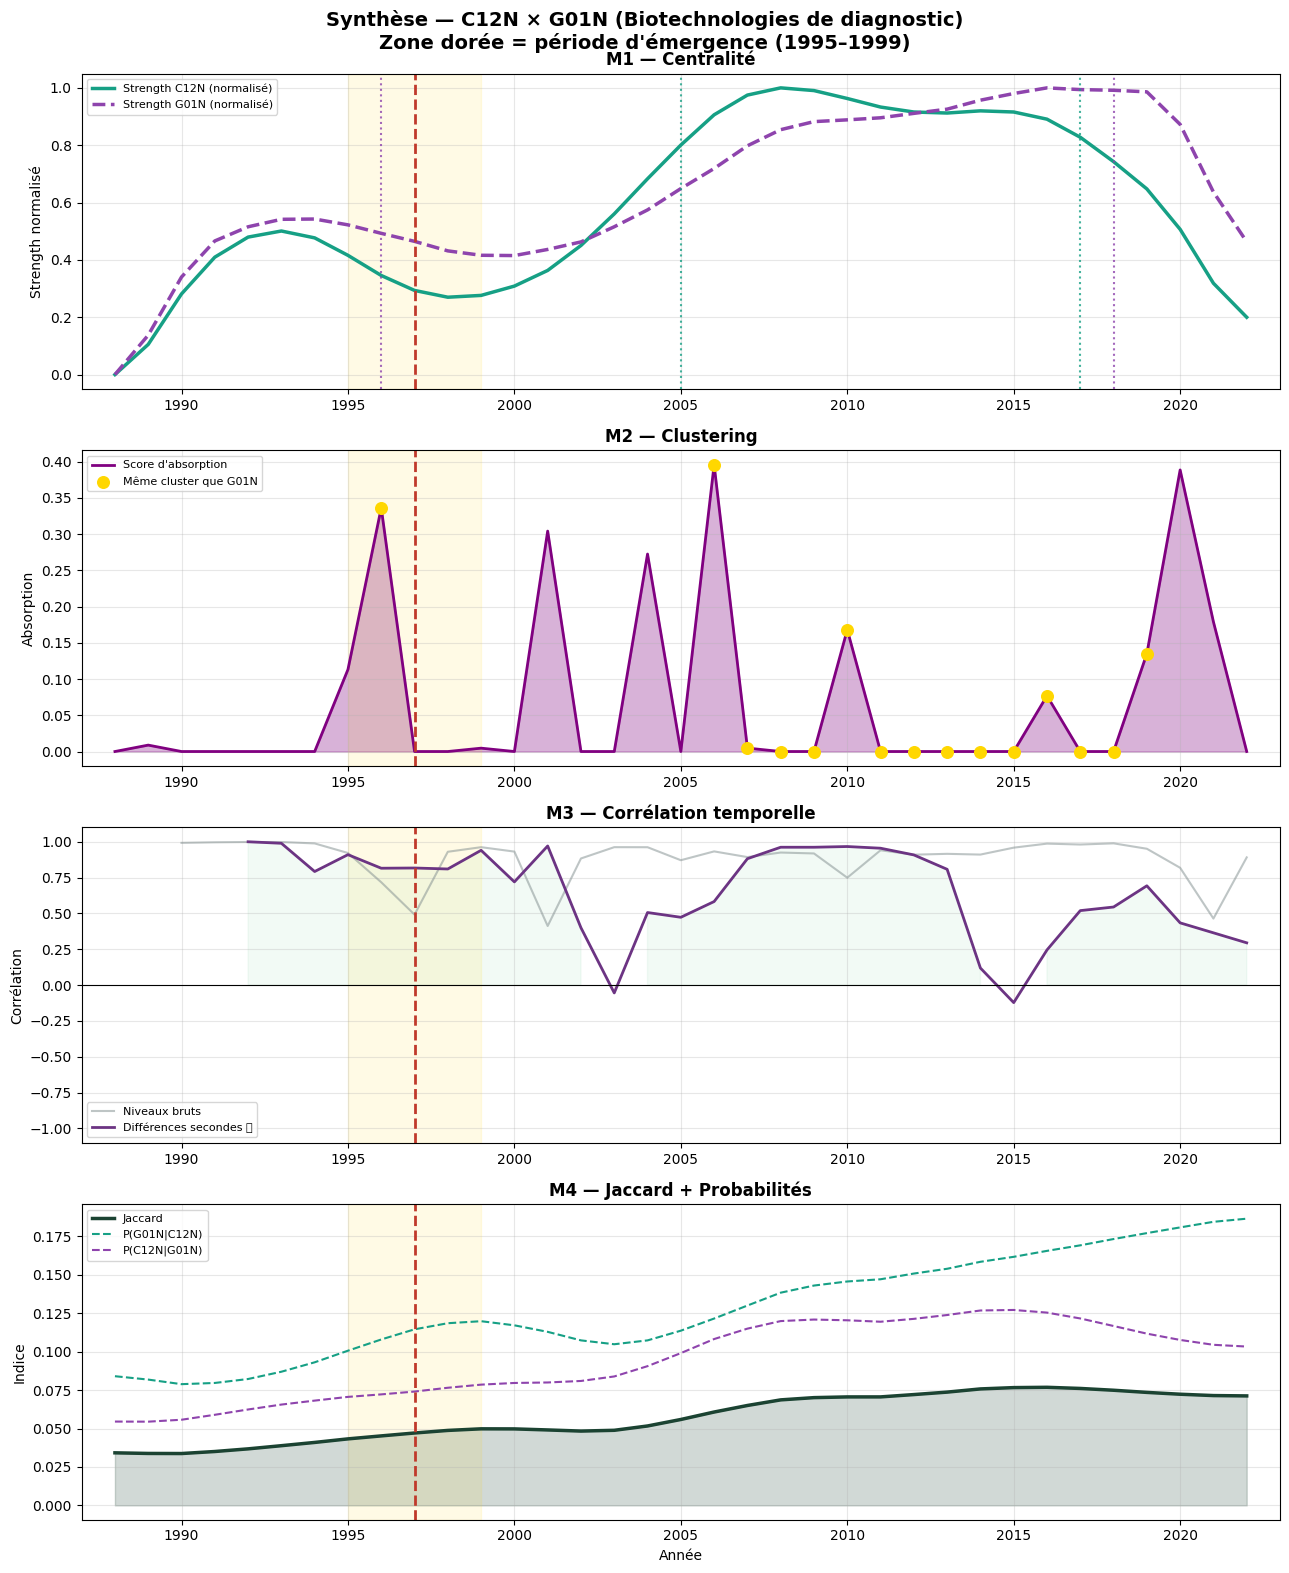


✅ Analyse Biotechnologies de diagnostic terminée.
Ratio de symétrie post-1997 : 0.747

Comparaison des trois cas :
  VE (H01M×B60L)    : ratio 0.42 → Bilatéral asymétrique
  Smartphone (G06F×H04W) : ratio ~0.39 → Bilatéral asymétrique
  Biotech (C12N×G01N)   : ratio 0.75 → voir verdict


In [17]:
fig,axes=plt.subplots(4,1,figsize=(13,16))

ax=axes[0]
yi_n=(yi_s-yi_s.min())/(yi_s.max()-yi_s.min())
yj_n=(yj_s-yj_s.min())/(yj_s.max()-yj_s.min())
ax.plot(xi,yi_n,color=C_I,lw=2.5,label=f'Strength {CPC_I} (normalisé)')
ax.plot(xj,yj_n,color=C_J,lw=2.5,ls='--',label=f'Strength {CPC_J} (normalisé)')
for b in breaks_i: ax.axvline(b,color=C_I,ls=':',lw=1.5,alpha=0.8)
for b in breaks_j: ax.axvline(b,color=C_J,ls=':',lw=1.5,alpha=0.8)
ax.axvline(YEAR_EMERGE,color=C_RUPTURE,ls='--',lw=2)
ax.axvspan(YEAR_EMERGE-2,YEAR_EMERGE+2,alpha=0.1,color='gold')
ax.set_ylabel('Strength normalisé')
ax.set_title('M1 — Centralité',fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax=axes[1]
ax.fill_between(df_traj['year'],0,df_traj['absorption'],alpha=0.3,color='purple')
ax.plot(df_traj['year'],df_traj['absorption'],color='purple',lw=2,
        label="Score d'absorption")
same_yr=df_traj[df_traj['same']]
ax.scatter(same_yr['year'],same_yr['absorption'],color='gold',s=70,
           zorder=5,label='Même cluster que G01N')
ax.axvline(YEAR_EMERGE,color=C_RUPTURE,ls='--',lw=2)
ax.axvspan(YEAR_EMERGE-2,YEAR_EMERGE+2,alpha=0.1,color='gold')
ax.set_ylabel('Absorption')
ax.set_title('M2 — Clustering',fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax=axes[2]
ax.plot(corr_niveaux.index,corr_niveaux.values,color='#7F8C8D',lw=1.5,
        alpha=0.5,label='Niveaux bruts')
ax.plot(corr_diff2.index,corr_diff2.values,color='#6C3483',lw=2,
        label='Différences secondes ✅')
ax.fill_between(corr_diff2.index,0,corr_diff2.values,
                where=corr_diff2.values>=0,alpha=0.15,color=C_POS)
ax.fill_between(corr_diff2.index,0,corr_diff2.values,
                where=corr_diff2.values<0,alpha=0.15,color=C_NEG)
ax.axhline(0,color='black',lw=0.8)
ax.axvline(YEAR_EMERGE,color=C_RUPTURE,ls='--',lw=2)
ax.axvspan(YEAR_EMERGE-2,YEAR_EMERGE+2,alpha=0.1,color='gold')
ax.set_ylim(-1.1,1.1); ax.set_ylabel('Corrélation')
ax.set_title('M3 — Corrélation temporelle',fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax=axes[3]
ax.fill_between(x,0,jac,alpha=0.2,color=C_JACCARD)
ax.plot(x,jac,color=C_JACCARD,lw=2.5,label='Jaccard')
ax.plot(x,pji,color=C_I,lw=1.5,ls='--',label=f'P({CPC_J}|{CPC_I})')
ax.plot(x,pij,color=C_J,lw=1.5,ls='--',label=f'P({CPC_I}|{CPC_J})')
ax.axvline(YEAR_EMERGE,color=C_RUPTURE,ls='--',lw=2)
ax.axvspan(YEAR_EMERGE-2,YEAR_EMERGE+2,alpha=0.1,color='gold')
ax.set_ylabel('Indice'); ax.set_xlabel('Année')
ax.set_title('M4 — Jaccard + Probabilités',fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

for ax in axes: ax.set_xlim(YEAR_START-1,YEAR_END+1)
plt.suptitle(f'Synthèse — C12N × G01N (Biotechnologies de diagnostic)\n'
             f'Zone dorée = période d\'émergence ({YEAR_EMERGE-2}–{YEAR_EMERGE+2})',
             fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('SYNTHESE_biotech.png',dpi=150,bbox_inches='tight')
plt.show()

print('\n✅ Analyse Biotechnologies de diagnostic terminée.')
print(f'Ratio de symétrie post-{YEAR_EMERGE} : {ratio_post:.3f}')
print('\nComparaison des trois cas :')
print('  VE (H01M×B60L)    : ratio 0.42 → Bilatéral asymétrique')
print('  Smartphone (G06F×H04W) : ratio ~0.39 → Bilatéral asymétrique')
print(f'  Biotech (C12N×G01N)   : ratio {ratio_post:.2f} → voir verdict')